# Probing in Code LLMs — Index/Key on CodeComplex (Java)

Tests whether probes trained on XLCoST generalise to a more complex, organic dataset,
and whether probes trained on CodeComplex agree with XLCoST-trained probes.

Dataset: `codeparrot/codecomplex` — ~4,500 complete Java Codeforces submissions annotated with time complexity.

In [16]:
!pip install transformers torch scikit-learn datasets matplotlib seaborn tqdm

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from collections import defaultdict
import re
import warnings
warnings.filterwarnings('ignore')  # suppress the sklearn/tqdm noise — gets annoying fast

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # use GPU if it's there, otherwise fall back to CPU
print(f'Using device: {DEVICE}')

zsh:1: /Applications/Projects/Algoverse/Coding/algoverse/bin/pip: bad interpreter: /Applications/Projects/Algoverse/XLCoST/algoverse/bin/python: no such file or directory
Using device: cpu


In [17]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'

print(f'Loading tokenizer and model: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)  # needed for Qwen — it has custom model code

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token  # Qwen has no separate pad token, eos works fine here

model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True, trust_remote_code=True)  # needed for Qwen — it has custom model code
model.eval()  # inference only, no gradients needed
model.to(DEVICE)  # move weights to GPU if available

# grab these once — reuse later
NUM_LAYERS  = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size
print(f'Layers: {NUM_LAYERS}, Hidden size: {HIDDEN_SIZE}')

_probe_ids = tokenizer('x', return_tensors='pt')['input_ids'][0].tolist()
_raw_len   = len(tokenizer.tokenize('x'))
LEADING_SPECIAL = len(_probe_ids) - _raw_len  # BERT has [CLS] so offset=1; Qwen has none so offset=0
print(f'Leading special tokens: {LEADING_SPECIAL}')

Loading tokenizer and model: Qwen/Qwen2.5-1.5B ...


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 5480.72it/s]

Layers: 28, Hidden size: 1536
Leading special tokens: 0


## Load CodeComplex Dataset

In [18]:
!pip install datasets
from datasets import load_dataset

print('Loading codeparrot/codecomplex ...')
ds = load_dataset('codeparrot/codecomplex', split='train')
print(f'Total samples: {len(ds)}')
print(f'Fields: {ds.column_names}')
print(f'Complexity classes: {set(ds["complexity"])}')
print()
print('── Sample program ──────────────────────────────────')
print(ds[0]['src'][:600])

zsh:1: /Applications/Projects/Algoverse/Coding/algoverse/bin/pip: bad interpreter: /Applications/Projects/Algoverse/XLCoST/algoverse/bin/python: no such file or directory
Loading codeparrot/codecomplex ...
Total samples: 4517
Fields: ['src', 'complexity', 'problem', 'from']
Complexity classes: {'logn', 'nlogn', 'constant', 'linear', 'cubic', 'quadratic', 'np'}

── Sample program ──────────────────────────────────
import java.io.*;
import java.math.BigInteger;
import java.util.InputMismatchException;
import java.util.PriorityQueue;
import java.util.StringTokenizer;

public class D {
    static class FastWriter {
        private final BufferedWriter bw;

        public FastWriter() {
            this.bw = new BufferedWriter(new OutputStreamWriter(System.out));
        }

        public void print(Object object) throws IOException {
            bw.append("" + object);
        }

        public void println(Object object) throws IOException {
            print(object);
            bw.appen

In [19]:
# Complexity class distribution
from collections import Counter
counts = Counter(ds['complexity'])
print('Complexity class distribution:')
for cls, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f'  {cls:12s}: {n}')

Complexity class distribution:
  linear      : 717
  nlogn       : 672
  constant    : 662
  quadratic   : 648
  logn        : 618
  cubic       : 600
  np          : 600


## Token Labeling - Index/Key Role (Java)

In [20]:
def get_java_index_key_names(code):
    """
    Returns variable names used as array indices or map keys in Java code.
    Captures: arr[i], dp[j], grid[row][col], map.get(key), map.containsKey(key)
    Excludes: integer literals like arr[0] and Java keywords.
    """
    indices = set()
    for m in re.finditer(r'\[\s*([a-zA-Z_]\w*)\s*\]', code):
        indices.add(m.group(1))
    for m in re.finditer(r'\.(?:get|containsKey|getOrDefault)\(\s*([a-zA-Z_]\w*)', code):
        indices.add(m.group(1))
    indices -= {'int', 'long', 'char', 'byte', 'short', 'boolean',
                'String', 'Integer', 'Long', 'Object', 'null', 'true', 'false'}
    return indices


def label_tokens(code, target_names):
    """
    Tokenize code and label each token: 1 if it resolves to a target name, 0 otherwise.
    Handles Qwen bracket-merging quirk (e.g. '[i' -> matches 'i').
    """
    if not target_names:  # nothing to label if no index vars were found
        return [], []
    tokens = tokenizer.tokenize(code)
    labels = []
    for tok in tokens:
        is_continuation = tok.startswith('##')  # BERT wordpiece continuation tokens — skip these
        clean = tok.lstrip('Ġ▁Ā').lstrip('##')  # GPT-style tokenizers prefix spaces with Ġ
        clean_inner = clean.strip('[]().,;:')
        matched = (not is_continuation) and (clean in target_names or clean_inner in target_names)
        labels.append(1 if matched else 0)
    return tokens, labels


# Quick verification
test_code = 'int[] dp = new int[n]; for (int i = 0; i < n; i++) dp[i] = map.get(key);'
names = get_java_index_key_names(test_code)
print('Detected index/key names:', names)
toks, labs = label_tokens(test_code, names)
for tok, lab in zip(toks, labs):
    if lab:
        print(f'  {repr(tok):20s}  <-- INDEX/KEY')

Detected index/key names: {'n', 'key', 'i'}
  '[n'                  <-- INDEX/KEY
  'Ġi'                  <-- INDEX/KEY
  'Ġi'                  <-- INDEX/KEY
  'Ġn'                  <-- INDEX/KEY
  'Ġi'                  <-- INDEX/KEY
  '[i'                  <-- INDEX/KEY
  '(key'                <-- INDEX/KEY


In [23]:
# Build labeled dataset from CodeComplex
MAX_PROGRAMS = 300  # cap for faster iteration

cc_data = []
skipped = 0
programs = ds['src'][:MAX_PROGRAMS]

for code in programs:
    names = get_java_index_key_names(code)
    if not names:
        skipped += 1
        continue
    tokens, labels = label_tokens(code, names)
    if not tokens or sum(labels) == 0:  # skip programs where none of the index vars survived tokenization
        skipped += 1
        continue
    cc_data.append({'code': code, 'tokens': tokens, 'labels': labels, 'target_names': names})

total_pos = sum(sum(d['labels']) for d in cc_data)
total_tok = sum(len(d['tokens']) for d in cc_data)
print(f'Programs with labels: {len(cc_data)}  ({skipped} skipped)')
print(f'Positive tokens: {total_pos} / {total_tok}  ({100*total_pos/total_tok:.1f}% positive)')

Programs with labels: 205  (95 skipped)
Positive tokens: 8468 / 152477  (5.6% positive)


## Class Distribution & Imbalance Check

## Hidden State Extraction

In [24]:
# progress bars — helpful when extraction takes a while
from tqdm.auto import tqdm

# anything longer than this gets truncated
MAX_SEQ_LEN = 512

def extract_hidden_states(dataset):
    all_hidden     = defaultdict(list)
    all_labels     = []
    all_token_strs = []

    with torch.no_grad():  # saves memory — we're not doing any backprop
        for sample in tqdm(dataset, desc='Extracting hidden states'):
            code   = sample['code']
            labels = sample['labels']

            encoding = tokenizer(
                code,
                return_tensors='pt',
                truncation=True,
                max_length=MAX_SEQ_LEN,
                padding=False,  # no padding since we're processing one at a time
            ).to(DEVICE)

            encoded_len = encoding['input_ids'].shape[1]  # actual length after truncation — not the same as pre-tokenize count
            n_content   = encoded_len - LEADING_SPECIAL  # strip the leading special token(s) before aligning labels

            tokens_no_special = tokenizer.tokenize(code)
            labels_trunc = labels[:n_content]
            tokens_trunc = tokens_no_special[:n_content]

            outputs       = model(**encoding)
            hidden_states = outputs.hidden_states

            start = LEADING_SPECIAL
            end   = start + n_content

            for layer_idx, layer_hs in enumerate(hidden_states):
                content_hs = layer_hs[0, start:end, :].float().cpu().numpy()  # Qwen uses bfloat16 by default — numpy can't handle it, cast first
                for vec in content_hs:
                    all_hidden[layer_idx].append(vec)  # accumulate per layer — will stack into an array at the end

            all_labels.extend(labels_trunc)
            all_token_strs.extend(tokens_trunc)

    for layer_idx in all_hidden:
        all_hidden[layer_idx] = np.stack(all_hidden[layer_idx])  # convert list of vectors to a proper 2D array

    return all_hidden, np.array(all_labels), all_token_strs


print('Extracting hidden states for CodeComplex ...')
cc_hidden, cc_labels, cc_tokens = extract_hidden_states(cc_data)
print(f'Shape at layer 0: {cc_hidden[0].shape}')
print(f'Label distribution: {np.bincount(cc_labels)}  (0=non-index, 1=index/key)')

Extracting hidden states for CodeComplex ...


Extracting hidden states: 100%|██████████| 205/205 [37:28<00:00, 10.97s/it]


Shape at layer 0: (85406, 1536)
Label distribution: [80098  5308]  (0=non-index, 1=index/key)


In [25]:
# ── Class distribution & imbalance check ─────────────────────────────────────
counts   = np.bincount(cc_labels)
total    = len(cc_labels)
n_neg, n_pos = counts[0], counts[1]
print('Class distribution (CodeComplex tokens):')
print(f'  Non-index (0): {n_neg:>7,}  ({100*n_neg/total:.1f}%)')
print(f'  Index/Key (1): {n_pos:>7,}  ({100*n_pos/total:.1f}%)')
print(f'  Imbalance ratio: {n_neg/n_pos:.1f}:1  (non-index : index)')
print()
print(f'  Naive all-zero baseline accuracy: {100*n_neg/total:.1f}%')
print('  (Probe accuracy near this = probe learned nothing useful.)')

Class distribution (CodeComplex tokens):
  Non-index (0):  80,098  (93.8%)
  Index/Key (1):   5,308  (6.2%)
  Imbalance ratio: 15.1:1  (non-index : index)

  Naive all-zero baseline accuracy: 93.8%
  (Probe accuracy near this = probe learned nothing useful.)


## Probe Training (CodeComplex-trained probes)

In [26]:
def train_probes(hidden_states_by_layer, labels, test_size=0.2, random_state=42):  # 80/20 split
    n = len(labels)
    train_idx, test_idx = train_test_split(
        np.arange(n), test_size=test_size, random_state=random_state, stratify=labels  # make sure both train and test have the same class ratio
    )

    results = {}
    for layer_idx in tqdm(sorted(hidden_states_by_layer.keys()), desc='Training probes'):
        X = hidden_states_by_layer[layer_idx]
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]

        clf = LogisticRegression(max_iter=1000, class_weight='balanced',  # index tokens are ~6% of all tokens — need to reweight or probe ignores them
                                 random_state=random_state, C=1.0)  # standard regularization, didn't tune this
        clf.fit(X_train, y_train)

        y_train_pred = clf.predict(X_train)
        y_test_pred  = clf.predict(X_test)
        results[layer_idx] = {
            'train_acc': accuracy_score(y_train, y_train_pred),
            'test_acc':  accuracy_score(y_test,  y_test_pred),
            'train_f1':  f1_score(y_train, y_train_pred, average='macro'),  # macro F1 is fairer given the class imbalance
            'test_f1':   f1_score(y_test,  y_test_pred,  average='macro'),  # macro F1 is fairer given the class imbalance
            'probe':     clf,
            'test_idx':  test_idx,
        }
    return results


print('Training probes on CodeComplex data ...')
cc_results = train_probes(cc_hidden, cc_labels)

Training probes on CodeComplex data ...


Training probes: 100%|██████████| 29/29 [12:16<00:00, 25.41s/it]


## Evaluation — Per-Layer Accuracy & F1

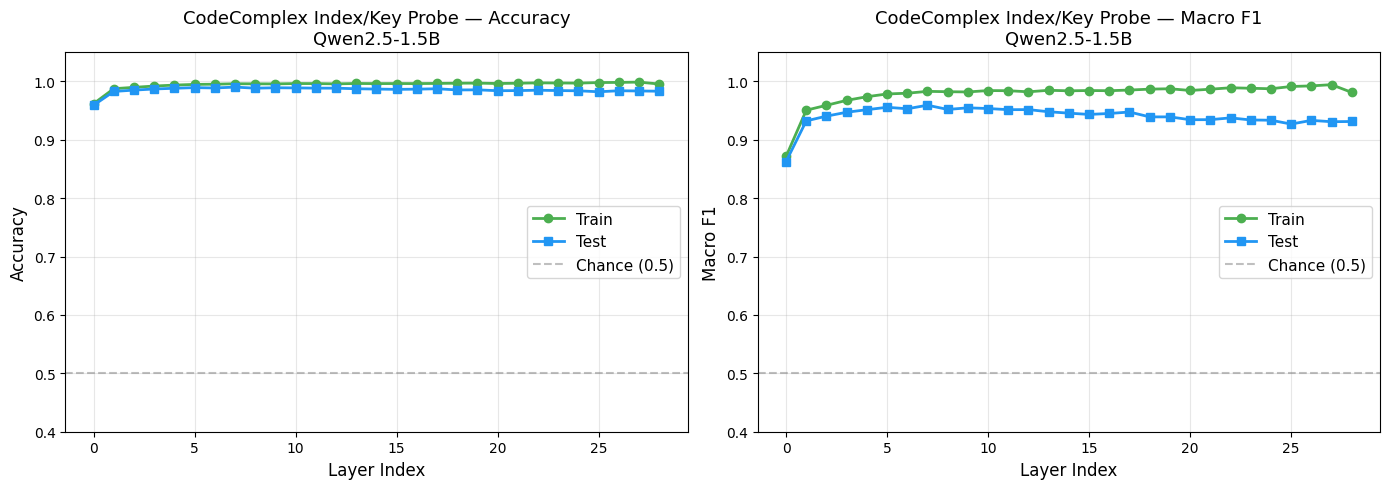

Saved: results/codecomplex/probe_accuracy_f1_codecomplex.png


In [27]:
layers     = sorted(cc_results.keys())
test_accs  = [cc_results[l]['test_acc']  for l in layers]
train_accs = [cc_results[l]['train_acc'] for l in layers]
test_f1s   = [cc_results[l]['test_f1']   for l in layers]
train_f1s  = [cc_results[l]['train_f1']  for l in layers]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, train_vals, test_vals, ylabel in zip(
    axes,
    [train_accs, train_f1s],
    [test_accs,  test_f1s],
    ['Accuracy', 'Macro F1'],
):
    ax.plot(layers, train_vals, marker='o', color='#4CAF50', linewidth=2, label='Train')
    ax.plot(layers, test_vals,  marker='s', color='#2196F3', linewidth=2, label='Test')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance (0.5)')  # chance-level for a balanced binary probe
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'CodeComplex Index/Key Probe — {ylabel}\n{MODEL_NAME.split("/")[-1]}', fontsize=13)
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible

plt.tight_layout()
plt.savefig('../results/codecomplex/probe_accuracy_f1_codecomplex.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
plt.show()
print('Saved: results/codecomplex/probe_accuracy_f1_codecomplex.png')

In [28]:
print(f'{"Layer":>7}  {"Train Acc":>10}  {"Test Acc":>10}  {"Train F1":>10}  {"Test F1":>10}')
print('-' * 60)
for l in layers:
    print(f'{l:>7}  {cc_results[l]["train_acc"]:>10.3f}  {cc_results[l]["test_acc"]:>10.3f}  '
          f'{cc_results[l]["train_f1"]:>10.3f}  {cc_results[l]["test_f1"]:>10.3f}')

  Layer   Train Acc    Test Acc    Train F1     Test F1
------------------------------------------------------------
      0       0.962       0.959       0.871       0.863
      1       0.987       0.983       0.951       0.932
      2       0.990       0.985       0.959       0.940
      3       0.992       0.987       0.967       0.947
      4       0.994       0.988       0.974       0.951
      5       0.995       0.989       0.978       0.956
      6       0.995       0.989       0.980       0.953
      7       0.996       0.990       0.983       0.959
      8       0.996       0.988       0.982       0.952
      9       0.996       0.989       0.982       0.955
     10       0.996       0.989       0.984       0.953
     11       0.996       0.988       0.984       0.951
     12       0.996       0.988       0.982       0.952
     13       0.996       0.987       0.985       0.948
     14       0.996       0.987       0.984       0.946
     15       0.996       0.986       0.984

In [29]:
best_layer = max(cc_results, key=lambda l: cc_results[l]['test_f1'])
test_idx   = cc_results[best_layer]['test_idx']
clf        = cc_results[best_layer]['probe']

X_test = cc_hidden[best_layer][test_idx]
y_test = cc_labels[test_idx]
y_pred = clf.predict(X_test)

print(f'Best layer: {best_layer}  (test F1: {cc_results[best_layer]["test_f1"]:.3f})')
print()
print(classification_report(y_test, y_pred, target_names=['non-index', 'index_key']))

Best layer: 7  (test F1: 0.959)

              precision    recall  f1-score   support

   non-index       1.00      0.99      0.99     16020
   index_key       0.89      0.96      0.92      1062

    accuracy                           0.99     17082
   macro avg       0.94      0.98      0.96     17082
weighted avg       0.99      0.99      0.99     17082



In [30]:
# ── Confusion matrix at best layer ────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print('Confusion matrix (best layer, test set):')
print(f'  True  Negatives (TN): {tn:>6,}  correctly predicted non-index')
print(f'  False Positives (FP): {fp:>6,}  non-index predicted as index')
print(f'  False Negatives (FN): {fn:>6,}  index missed')
print(f'  True  Positives (TP): {tp:>6,}  correctly predicted index')
print()
print(f'  TPR (recall):    {tp/(tp+fn):.3f}')
print(f'  FPR:             {fp/(fp+tn):.3f}')
print(f'  Precision:       {tp/(tp+fp):.3f}')
print(f'  Pred positive rate: {(tp+fp)/len(y_test):.3f}  (vs true rate {(tp+fn)/len(y_test):.3f})')

Confusion matrix (best layer, test set):
  True  Negatives (TN): 15,893  correctly predicted non-index
  False Positives (FP):    127  non-index predicted as index
  False Negatives (FN):     42  index missed
  True  Positives (TP):  1,020  correctly predicted index

  TPR (recall):    0.960
  FPR:             0.008
  Precision:       0.889
  Pred positive rate: 0.067  (vs true rate 0.062)


## Cross-Dataset Generalization

Load the XLCoST-trained Java probe (from `probing_variable_roles.ipynb`) and apply it
directly to CodeComplex hidden states — no retraining.

**If you have already run `probing_variable_roles.ipynb` in the same kernel, `idx_results`
and `java_idx_hidden` / `java_idx_labels` are already in memory. Otherwise re-run that
notebook first, or retrain below.**

In [33]:
# ── Option A: use XLCoST Java probe already in memory ─────────────────────────
# (assumes java_idx_results from probing_variable_roles.ipynb is available)
# If not, skip to Option B below.

try:
    _ = java_idx_results  # check if in memory
    xlcost_java_results = java_idx_results
    print('Using XLCoST Java probe already in memory.')
except NameError:
    print('XLCoST Java probe not in memory — run probing_variable_roles.ipynb first, or use Option B.')
    xlcost_java_results = None

XLCoST Java probe not in memory — run probing_variable_roles.ipynb first, or use Option B.


In [37]:
# ── Option B: retrain XLCoST Java probe from scratch ─────────────────────────
# Run this cell only if xlcost_java_results is None above.

if xlcost_java_results is None:
    import os, json as _json

    # adjust this path if the data is somewhere else
    XLCOST_ROOT = '/Applications/Projects/Algoverse/CODING/XLCoST_data'

    def reconstruct_code(tokens):  # XLCoST stores code as token lists with indent markers
        indent_level, lines, current_line = 0, [], []
        for tok in tokens:
            if tok == 'NEW_LINE':  # XLCoST encodes newlines as explicit tokens
                lines.append('    ' * indent_level + ' '.join(current_line))
                current_line = []
            elif tok == 'INDENT':  # indentation is tracked via these special tokens
                indent_level += 1
            elif tok == 'DEDENT':
                indent_level = max(0, indent_level - 1)
            else:
                current_line.append(tok)
        if current_line:
            lines.append('    ' * indent_level + ' '.join(current_line))
        return '\n'.join(lines).strip()

    path = os.path.join(XLCOST_ROOT, 'retrieval', 'nl2code_search', 'program_level', 'Java', 'train.jsonl')
    java_programs_xlcost = []
    with open(path) as f:
        for line in f:
            if len(java_programs_xlcost) >= 300:
                break
            rec  = _json.loads(line.strip())  # each line in the .jsonl is one program
            code = reconstruct_code(rec['code_tokens'])  # XLCoST stores code as token lists with indent markers
            if code:
                java_programs_xlcost.append(code)

    xlcost_java_data = []
    for code in java_programs_xlcost:
        names = get_java_index_key_names(code)
        if not names:
            continue
        tokens, labels = label_tokens(code, names)
        if tokens and sum(labels) > 0:
            xlcost_java_data.append({'code': code, 'tokens': tokens, 'labels': labels, 'target_names': names})

    print(f'XLCoST Java programs with labels: {len(xlcost_java_data)}')
    print('Extracting hidden states for XLCoST Java ...')
    xlcost_java_hidden, xlcost_java_labels, _ = extract_hidden_states(xlcost_java_data)
    print('Training XLCoST Java probe ...')
    xlcost_java_results = train_probes(xlcost_java_hidden, xlcost_java_labels)
    print('Done.')

XLCoST Java programs with labels: 100
Extracting hidden states for XLCoST Java ...


Extracting hidden states: 100%|██████████| 100/100 [10:11<00:00,  6.11s/it]


Training XLCoST Java probe ...


Training probes: 100%|██████████| 29/29 [01:17<00:00,  2.66s/it]

Done.


In [38]:
# ── Apply XLCoST Java probe to CodeComplex hidden states ──────────────────────
if xlcost_java_results is not None:
    xlcost_to_cc = {
        l: f1_score(cc_labels,
                    xlcost_java_results[l]['probe'].predict(cc_hidden[l]),
                    average='macro')
        for l in layers
    }
    xlcost_to_cc_acc = {
        l: accuracy_score(cc_labels, xlcost_java_results[l]['probe'].predict(cc_hidden[l]))
        for l in layers
    }

    print(f'{"Layer":>7}  {"CC probe test F1":>18}  {"XLCoST->CC F1":>15}  {"XLCoST->CC Acc":>15}')
    print('-' * 60)
    for l in layers:
        print(f'{l:>7}  {cc_results[l]["test_f1"]:>18.3f}  {xlcost_to_cc[l]:>15.3f}  {xlcost_to_cc_acc[l]:>15.3f}')

  Layer    CC probe test F1    XLCoST->CC F1   XLCoST->CC Acc
------------------------------------------------------------
      0               0.863            0.859            0.969
      1               0.932            0.818            0.959
      2               0.940            0.815            0.959
      3               0.947            0.828            0.962
      4               0.951            0.811            0.959
      5               0.956            0.862            0.970
      6               0.953            0.890            0.973
      7               0.959            0.905            0.979
      8               0.952            0.903            0.977
      9               0.955            0.889            0.973
     10               0.953            0.908            0.978
     11               0.951            0.907            0.978
     12               0.952            0.907            0.978
     13               0.948            0.911            0.980
     14  

In [39]:
# ── Apply CodeComplex probe back to XLCoST Java ───────────────────────────────
if xlcost_java_results is not None:
    try:
        xh = xlcost_java_hidden
        xl = xlcost_java_labels
    except NameError:
        print('xlcost_java_hidden not in scope — run Option B cell above first.')
        xh = xl = None

    if xh is not None:
        cc_to_xlcost = {
            l: f1_score(xl, cc_results[l]['probe'].predict(xh[l]), average='macro')  # macro F1 is fairer given the class imbalance
            for l in layers
        }
        print(f'{"Layer":>7}  {"XLCoST probe test F1":>22}  {"CC->XLCoST F1":>14}')
        print('-' * 50)
        for l in layers:
            xl_f1 = xlcost_java_results[l]['test_f1']
            print(f'{l:>7}  {xl_f1:>22.3f}  {cc_to_xlcost[l]:>14.3f}')

  Layer    XLCoST probe test F1   CC->XLCoST F1
--------------------------------------------------
      0                   0.901           0.847
      1                   0.939           0.885
      2                   0.962           0.891
      3                   0.965           0.882
      4                   0.963           0.881
      5                   0.966           0.889
      6                   0.967           0.890
      7                   0.976           0.861
      8                   0.983           0.869
      9                   0.975           0.872
     10                   0.973           0.864
     11                   0.971           0.836
     12                   0.977           0.848
     13                   0.971           0.864
     14                   0.977           0.865
     15                   0.974           0.877
     16                   0.976           0.877
     17                   0.976           0.870
     18                   0.967      

## Probe Weight Similarity (Cosine)

Compares the linear direction each probe uses to detect index/key tokens.
High cosine similarity means both datasets encode the concept in the same direction in the model's latent space.

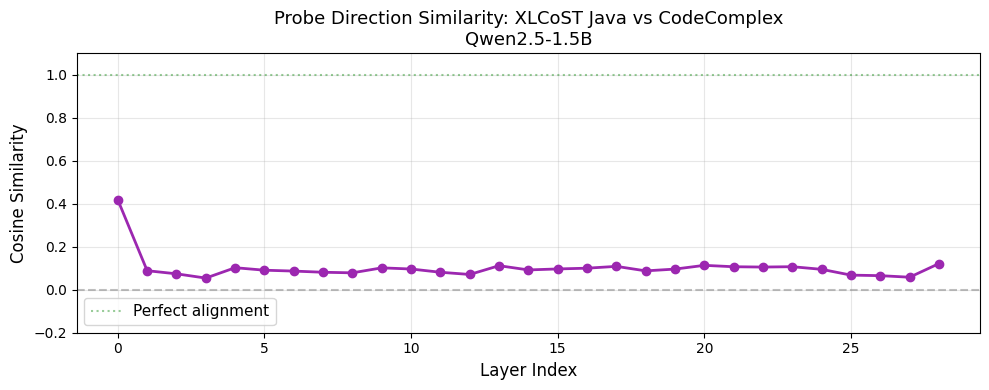

Saved: results/codecomplex/cosine_similarity_xlcost_vs_codecomplex.png

Cosine similarities by layer:
  Layer  0: 0.4175
  Layer  1: 0.0884
  Layer  2: 0.0739
  Layer  3: 0.0541
  Layer  4: 0.1023
  Layer  5: 0.0907
  Layer  6: 0.0866
  Layer  7: 0.0812
  Layer  8: 0.0785
  Layer  9: 0.1016
  Layer 10: 0.0962
  Layer 11: 0.0811
  Layer 12: 0.0708
  Layer 13: 0.1117
  Layer 14: 0.0920
  Layer 15: 0.0966
  Layer 16: 0.1001
  Layer 17: 0.1085
  Layer 18: 0.0876
  Layer 19: 0.0959
  Layer 20: 0.1133
  Layer 21: 0.1068
  Layer 22: 0.1053
  Layer 23: 0.1070
  Layer 24: 0.0947
  Layer 25: 0.0678
  Layer 26: 0.0653
  Layer 27: 0.0581
  Layer 28: 0.1214


In [40]:
from numpy.linalg import norm

if xlcost_java_results is not None:
    similarities = []
    for l in layers:
        w_cc     = cc_results[l]['probe'].coef_[0]
        w_xlcost = xlcost_java_results[l]['probe'].coef_[0]
        similarities.append(np.dot(w_cc, w_xlcost) / (norm(w_cc) * norm(w_xlcost)))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(layers, similarities, marker='o', color='#9C27B0', linewidth=2)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)  # zero line for reference
    ax.axhline(1, color='green', linestyle=':', alpha=0.4, label='Perfect alignment')
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title(
        f'Probe Direction Similarity: XLCoST Java vs CodeComplex\n{MODEL_NAME.split("/")[-1]}',
        fontsize=13
    )
    ax.set_ylim(-0.2, 1.1)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible
    plt.tight_layout()
    plt.savefig('../results/codecomplex/cosine_similarity_xlcost_vs_codecomplex.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
    plt.show()
    print('Saved: results/codecomplex/cosine_similarity_xlcost_vs_codecomplex.png')

    print('\nCosine similarities by layer:')
    for l, s in zip(layers, similarities):
        print(f'  Layer {l:2d}: {s:.4f}')

In [ ]:
_save = '../results/codecomplex'
import os as _os; _os.makedirs(_save, exist_ok=True)

## Multi-Model Comparison

Repeat the same probing experiment with additional models.
Results are collected in `mm_results` keyed by model nickname.

In [ ]:
# ── Additional models to evaluate ─────────────────────────────────────────
ADDITIONAL_MODELS = {
    'CodeBERT':     'microsoft/codebert-base',   # code-specific BERT, 12 layers, 768-d
    'RoBERTa':      'roberta-base',               # general NLP baseline, 12 layers, 768-d
    'Qwen2.5-0.5B': 'Qwen/Qwen2.5-0.5B',         # smaller Qwen, 24 layers, 896-d
}
print('Additional models:', list(ADDITIONAL_MODELS.keys()))


In [ ]:
from transformers import AutoTokenizer, AutoModel as _AutoModel
from collections import defaultdict as _dd
import numpy as _np
# progress bars — helpful when extraction takes a while
from tqdm.auto import tqdm as _tqdm

def _detect_leading_special(tok):
    probe_ids = tok('x', return_tensors='pt')['input_ids'][0].tolist()
    return len(probe_ids) - len(tok.tokenize('x'))

def _label_tokens_generic(code, target_names, tok):
    if not target_names:  # nothing to label if no index vars were found
        return [], []
    tokens = tok.tokenize(code)
    labels = []
    for t in tokens:
        is_cont   = t.startswith('##')  # BERT wordpiece continuation tokens — skip these
        clean     = t.lstrip('Ġ▁Ā').lstrip('##')  # GPT-style tokenizers prefix spaces with Ġ
        clean_in  = clean.strip('[]().,;:')
        matched   = (not is_cont) and (clean in target_names or clean_in in target_names)
        labels.append(1 if matched else 0)
    return tokens, labels

def _extract_hs(dataset, tok, mdl, leading_special, max_seq=512, dev='cpu'):
    all_h  = _dd(list)
    all_l  = []
    with torch.no_grad():  # saves memory — we're not doing any backprop
        for s in _tqdm(dataset, desc='  hidden states', leave=False):
            code, labels = s['code'], s['labels']
            enc = tok(code, return_tensors='pt', truncation=True,
                      max_length=max_seq, padding=False).to(dev)  # no padding since we're processing one at a time
            n   = enc['input_ids'].shape[1] - leading_special
            out = mdl(**enc)

            # handle both encoder-only (hidden_states) and encoder-decoder
            hs  = out.hidden_states if hasattr(out, 'hidden_states') and out.hidden_states else None
            if hs is None:
                hs = out.encoder_hidden_states  # T5-style

            start, end = leading_special, leading_special + n
            for li, lhs in enumerate(hs):
                all_h[li].extend(lhs[0, start:end, :].float().cpu().numpy())  # Qwen uses bfloat16 by default — numpy can't handle it, cast first
            all_l.extend(labels[:n])
    for li in all_h:
        all_h[li] = _np.stack(all_h[li])  # convert list of vectors to a proper 2D array
    return all_h, _np.array(all_l)

def run_model_experiment(model_name, dataset, device=DEVICE):
    """Re-run the probing experiment end-to-end with a different model."""
    print(f'  Loading {model_name} ...')
    tok = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)  # needed for Qwen — it has custom model code
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token

    mdl = _AutoModel.from_pretrained(model_name, output_hidden_states=True,  # this is the whole point — need all layer outputs
                                      trust_remote_code=True)  # needed for Qwen — it has custom model code
    mdl.eval().to(device)

    ls  = _detect_leading_special(tok)
    n_layers = mdl.config.num_hidden_layers
    h_size   = mdl.config.hidden_size
    print(f'  Layers={n_layers}  Hidden={h_size}  LeadingSpecial={ls}')

    # Re-label with this tokenizer (same code, same index names, different tokens)
    new_dataset = []
    for s in dataset:
        toks, labs = _label_tokens_generic(s['code'], s['target_names'], tok)
        if toks and sum(labs) > 0:
            new_dataset.append({**s, 'tokens': toks, 'labels': labs})
    print(f'  Usable samples: {len(new_dataset)}/{len(dataset)}')

    h, lbs = _extract_hs(new_dataset, tok, mdl, ls, dev=device)

    del mdl   # free memory before next model
    torch.cuda.empty_cache() if device != 'cpu' else None

    results = train_probes(h, lbs)
    best_l  = max(results, key=lambda l: results[l]['test_f1'])
    print(f'  Best layer {best_l}: acc={results[best_l]["test_acc"]:.3f}  F1={results[best_l]["test_f1"]:.3f}')
    return results, h, lbs

print('Multi-model runner defined.')


In [ ]:
# ── Run all additional models ──────────────────────────────────────────────
# Seed with Qwen2.5-1.5B results already computed above
mm_results = {'Qwen2.5-1.5B (CC)': cc_results}
mm_hidden  = {'Qwen2.5-1.5B (CC)': cc_hidden}
mm_labels  = {'Qwen2.5-1.5B (CC)': cc_labels}

for nick, mname in ADDITIONAL_MODELS.items():
    print(f'\n{"="*55}')
    print(f'  Model: {nick} ({mname})')
    print(f'{"="*55}')
    try:
        res, h, lbs = run_model_experiment(mname, cc_data)
        mm_results[nick] = res
        mm_hidden[nick]  = h
        mm_labels[nick]  = lbs
    except Exception as e:
        print(f'  FAILED: {e}')

print('\nModels completed:', list(mm_results.keys()))


In [ ]:
# ── Plot: test F1 per layer, all models ───────────────────────────────────
MODEL_COLORS  = ['#FF5722','#2196F3','#4CAF50','#9C27B0','#FF9800','#00BCD4']
MODEL_MARKERS = ['o','s','^','D','P','X']

layers_mm = sorted(next(iter(mm_results.values())).keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, metric, ylabel in zip(axes, ['test_acc', 'test_f1'], ['Test Accuracy', 'Test Macro F1']):
    for i, (nick, res) in enumerate(mm_results.items()):
        vals = [res[l][metric] for l in layers_mm]
        ax.plot(layers_mm, vals,
                marker=MODEL_MARKERS[i % len(MODEL_MARKERS)],
                color=MODEL_COLORS[i % len(MODEL_COLORS)],
                linewidth=2, markersize=5, label=nick)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')  # chance-level for a balanced binary probe
    ax.set_xlabel('Layer Index', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'Index/Key Probe — {ylabel}\nAll Models', fontsize=12)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)  # slightly transparent so overlapping points are visible

plt.tight_layout()
_save = locals().get('RESULTS_DIR', '../results/more_perturbated_variables')
plt.savefig(f'{_save}/multimodel_comparison.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
plt.show()
print('Saved: multimodel_comparison.png')


In [ ]:
# ── Summary table: all models × best layer ────────────────────────────────
print(f'{"Model":18s}  {"Best Layer":>10}  {"Test Acc":>9}  {"Test F1":>8}')
print('-' * 52)
for nick, res in mm_results.items():
    best_l  = max(res, key=lambda l: res[l]['test_f1'])
    print(f'{nick:18s}  {best_l:>10d}  {res[best_l]["test_acc"]:>9.3f}  {res[best_l]["test_f1"]:>8.3f}')


## Cross-Model Transfer

Train probe on Model A's hidden states, evaluate directly on Model B's.
High F1 = the two models encode the index/key concept in similar directions.

In [ ]:
# ── Cross-model transfer matrix (F1) ─────────────────────────────────────
model_nicks = list(mm_results.keys())
n_models    = len(model_nicks)
xfer_matrix = _np.zeros((n_models, n_models))  # rows = train strategy/model, cols = test strategy/model

for i, src_nick in enumerate(model_nicks):
    for j, tgt_nick in enumerate(model_nicks):
        if src_nick not in mm_hidden or tgt_nick not in mm_hidden:
            xfer_matrix[i, j] = float('nan')  # rows = train strategy/model, cols = test strategy/model
            continue
        src_results = mm_results[src_nick]
        tgt_h       = mm_hidden[tgt_nick]
        tgt_lbs     = mm_labels[tgt_nick]

        # Use the best layer of the SOURCE model
        best_l = max(src_results, key=lambda l: src_results[l]['test_f1'])

        if best_l not in tgt_h:
            # Layer count mismatch — use the closest available layer
            available = sorted(tgt_h.keys())
            best_l    = min(available, key=lambda l: abs(l - best_l))  # nearest available layer if counts differ across models

        probe  = src_results[best_l]['probe']
        y_pred = probe.predict(tgt_h[best_l])
        xfer_matrix[i, j] = f1_score(tgt_lbs, y_pred, average='macro')  # macro F1 is fairer given the class imbalance

# Print matrix
print(f'Cross-model transfer F1  (row=train model, col=test model)')
print(f'{"":18s}', end='')
for nick in model_nicks:
    print(f'  {nick[:10]:>10s}', end='')
print()
print('-' * (18 + 13 * n_models))
for i, src in enumerate(model_nicks):
    print(f'{src:18s}', end='')
    for j in range(n_models):
        v = xfer_matrix[i, j]  # rows = train strategy/model, cols = test strategy/model
        print(f'  {v:>10.3f}' if not _np.isnan(v) else f'  {"N/A":>10s}', end='')  # some combos might fail (layer count mismatch etc)
    print()


In [ ]:
# ── Heatmap: cross-model transfer ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(6, n_models * 1.8), max(5, n_models * 1.5)))
mask = _np.isnan(xfer_matrix)  # rows = train strategy/model, cols = test strategy/model
im   = ax.imshow(_np.where(mask, 0, xfer_matrix), cmap='YlOrRd', vmin=0.5, vmax=1.0)  # rows = train strategy/model, cols = test strategy/model

ax.set_xticks(range(n_models)); ax.set_xticklabels(model_nicks, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(n_models)); ax.set_yticklabels(model_nicks, fontsize=9)
ax.set_xlabel('Test Model',  fontsize=11)
ax.set_ylabel('Train Model', fontsize=11)
ax.set_title('Cross-Model Transfer F1\n(probe trained on row, tested on col)', fontsize=12)

for i in range(n_models):
    for j in range(n_models):
        v = xfer_matrix[i, j]  # rows = train strategy/model, cols = test strategy/model
        txt = f'{v:.3f}' if not _np.isnan(v) else 'N/A'  # some combos might fail (layer count mismatch etc)
        ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                color='black' if v < 0.8 else 'white')

plt.colorbar(im, ax=ax, label='Macro F1', fraction=0.04, pad=0.02)
plt.tight_layout()
plt.savefig(f'{_save}/crossmodel_transfer_heatmap.png', dpi=150, bbox_inches='tight')  # high enough for slides/paper without being huge
plt.show()
print('Saved: crossmodel_transfer_heatmap.png')
